In [1]:
import sys
from pathlib import Path

import matplotlib as mpl

In [2]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [3]:
import src.compute.stats as stats_module
# from data import b_naive, b_memory

import importlib
import src.plot.tracks.reconstruct as reconstruct_module
import src.batch.tree as batch_tree_module
import src.io.load as load_module
import src.filter.filters as filters_module

In [4]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\mem_cxcl12\#memory-cxcl12#BC39#Stablized_spots.csv", retain=['POSITION_Z'], split_filename=True, split_filename_delimiter='#', split_filename_position=2)

In [5]:
importlib.reload(stats_module)

stats = stats_module.stats

spots = stats.spots(data)
spots

,track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set,frame,distance,cum_track_length,cum_track_displacement,...,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
track_uid,,,,,,,,,,,,,,,,,,,,,
0,196.0,0.0,446.049935,514.718016,0.0,BC39,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,46.0,0.0,105.142437,265.404884,0.0,BC39,0,422.344599,4.223446e+02,422.344599,...,NaN,3.519538,NaN,-2.510153,NaN,NaN,NaN,NaN,-2.510153,0.000000
0,193.0,0.0,57.339646,514.234949,0.0,BC39,0,253.380165,6.757248e+02,388.710589,...,NaN,2.159503,NaN,1.760594,115.304209,1.153042e+02,115.304209,0.640579,2.766813,0.464941
0,199.0,0.0,533.838219,533.021939,0.0,BC39,0,476.868789,1.152594e+03,89.676176,...,NaN,0.373651,NaN,0.039407,98.616773,2.139210e+02,106.960491,0.445669,1.562946,0.856285
0,198.0,0.0,962.196674,538.272284,0.0,BC39,0,428.390630,1.580984e+03,516.683907,...,NaN,1.722280,NaN,0.012256,1.555608,2.154766e+02,71.825530,0.239418,0.416118,0.725771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,723.0,3540.0,11.838741,321.551650,0.0,BC39,59,399.540816,1.219409e+07,475.239524,...,3444.657704,0.000326,9.455563e-08,2.625023,25.926157,2.900973e+06,119.303046,0.000082,-2.235701,0.996397
0,727.0,3540.0,41.932501,675.383134,0.0,BC39,59,355.108932,1.219444e+07,434.884100,...,3444.758017,0.000298,8.652027e-08,1.485949,65.264125,2.901038e+06,119.300824,0.000082,-2.242017,0.996432
0,726.0,3540.0,17.251840,588.025299,0.0,BC39,59,90.777345,1.219453e+07,435.019268,...,3444.783661,0.000298,8.654295e-08,-1.846144,169.085126,2.901207e+06,119.302871,0.000082,-2.237620,0.996394


In [6]:
importlib.reload(stats_module)

stats = stats_module.stats

tracks = stats.tracks(spots)
tracks

,set,track_id,POSITION_Z,track_length,speed_min,speed_max,speed_mean,speed_sd,speed_median,x_location,...,track_end_time,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_displacement,straightness_ratio,track_points
track_uid,,,,,,,,,,,,,,,,,,,,,
0,BC39,196.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,46.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,193.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,199.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,198.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,BC39,727.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,723.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,730.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322


In [7]:
importlib.reload(filters_module)

filter = filters_module.filter

Dropping 6 rows with non-finite/non-positive 'Track length'/'Straightness index' values


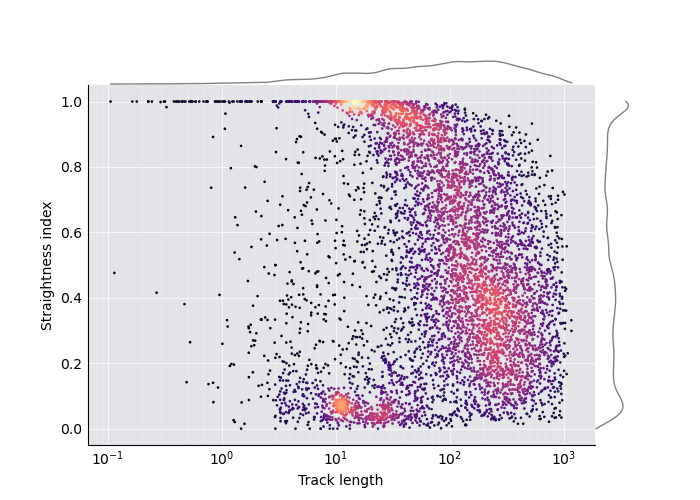

<module 'matplotlib.pyplot' from 'c:\\Users\\modri\\miniconda3\\envs\\peregrin\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [8]:
class InvalidParameterValueError(ValueError): ...

%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, NullFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

from matplotlib.widgets import Cursor

df = pd.read_csv(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\Track stats 2026-02-22.csv")


class Filter:

    def __init__(self):
        np.random.seed(42)

        self.df: pd.DataFrame = None


    def gate(
        self,
        df: pd.DataFrame,
        y: str,
        x: str,
        *,
        log: bool = False,
        **kwargs
    ) -> None:

        state = kwargs.get("state", None)

        # per-axis log flags; `log` kept for backward compatibility
        log_x = kwargs.get("log_x", log)
        log_y = kwargs.get("log_y", log)

        for _log in [log_x, log_y]:
            if not isinstance(_log, bool):
                raise InvalidParameterValueError(f"{_log} is not a valid log value; must be boolean (True/False)")

        if self.df is None:
            self.df = df

        if kwargs.get("sample_fraction", None) is not None:
            if not isinstance(kwargs["sample_fraction"], float) or not (0 < kwargs["sample_fraction"] <= 1):
                raise ValueError("sample_fraction must be a float between 0 and 1")
            df = df.sample(frac=kwargs["sample_fraction"]).reset_index(drop=True)
        else:
            if len(df) > 10000:
                df = df.sample(n=10000).reset_index(drop=True)

        xdata = df[x].to_numpy(float)
        ydata = df[y].to_numpy(float)

        # drop rows with NaN (or inf) in either coordinate
        finite = np.isfinite(xdata) & np.isfinite(ydata)
        # when using log scales, positive values are also required
        if log_x:
            finite &= xdata > 0
        if log_y:
            finite &= ydata > 0
        n_dropped = int((~finite).sum())
        if n_dropped:
            print(f"Dropping {n_dropped} rows with non-finite/non-positive {x!r}/{y!r} values")
        df = df.loc[finite].reset_index(drop=True)
        xdata = xdata[finite]
        ydata = ydata[finite]

        # values used for density/KDE (log-transformed where requested)
        xkde = np.log(xdata) if log_x else xdata
        ykde = np.log(ydata) if log_y else ydata

        # compute local point density (count) via Gaussian KDE
        # density = gaussian_kde(np.vstack([xkde, ykde]), bw_method=kwargs.get("kde_bw", "scott"))(np.vstack([xkde, ykde]))
        density = gaussian_kde(np.vstack([xkde, ykde]), bw_method=kwargs.get("kde_bw", "scott"))

        # sort so densest points are drawn on top
        # order = density.argsort()
        # xs, ys, dens = xdata[order], ydata[order], density[order]
        xs, ys, dens = xdata, ydata, density(np.vstack([xkde, ykde]))

        fig, ax = plt.subplots(figsize=(7, 5))
        pts = ax.scatter(xs, ys, c=dens, s=0.85, cmap=kwargs.get("cmap", "magma"), zorder=3)
        ax.set_xlabel(x)
        ax.set_ylabel(y)

        if log_y:
            ax.set_yscale('log', nonpositive='clip')
        if log_x:
            ax.set_xscale('log', nonpositive='clip')

        for axis in ["top", "right"]:
            ax.spines[axis].set_visible(False)

        ax.tick_params(axis="both", which="both", length=0)

        # --- marginal KDE plots on the top (x) and right (y) axes ---
        divider = make_axes_locatable(ax)
        ax_top = divider.append_axes("top", size="7%", pad=0, sharex=ax)
        ax_right = divider.append_axes("right", size="7%", pad=0, sharey=ax)

        _c = 'grey'
        _lw = 1

        # x marginal (top) -- KDE in log-space, plotted on log axis
        kde_x = gaussian_kde(xkde, bw_method=kwargs.get("kde_bw", "scott"))
        x_grid_kde = np.linspace(xkde.min(), xkde.max(), 400)
        x_dens = kde_x(x_grid_kde)
        x_grid = np.exp(x_grid_kde) if log_x else x_grid_kde
        ax_top.plot(x_grid, x_dens, color=_c, lw=_lw)
        ax_top.set_axis_off()

        # y marginal (right) -- KDE in log-space, plotted on log axis
        kde_y = gaussian_kde(ykde, bw_method=kwargs.get("kde_bw", "scott"))
        y_grid_kde = np.linspace(ykde.min(), ykde.max(), 400)
        y_dens = kde_y(y_grid_kde)
        y_grid = np.exp(y_grid_kde) if log_y else y_grid_kde
        ax_right.plot(y_dens, y_grid, color=_c, lw=_lw)
        ax_right.set_axis_off()

        # store the density-based facecolors so we can restore them after gating
        base_colors = pts.get_facecolors().copy()

        # store selection so you can use it in later cells
        selection = {"mask": None, "verts": None, "df": None}

        _color = '#002fff'
        _color2 = "#002fff4b"

        # Keep a reference on fig so the crosshair survives across cells.
        fig._cursor = Cursor(
            ax,
            useblit=True,
            color=_color2,
            linewidth=1,
            horizOn=True,
            vertOn=True,
        )

        def on_select(verts):
            path = Path(verts)
            inside = path.contains_points(np.column_stack([xs, ys]))
            colors = base_colors.copy()
            pts.set_facecolors(colors)
            fig.canvas.draw_idle()
            selection["mask"] = inside
            selection["verts"] = verts
            selection["df"] = df.loc[inside].reset_index(drop=True)
            print(f"{inside.sum()} points inside gate")

        ax.set_facecolor("#e3e4e7")
        # major + minor gridlines (minor lighter) so log spacing is visible
        ax.grid(True, which="major", color="white", linewidth=0.5, zorder=0)
        ax.grid(True, which="minor", color="white", linewidth=0.25, zorder=0, alpha=0.75)

        # keep a reference on fig so it survives across cells
        fig._poly_selector = PolygonSelector(
            ax,
            on_select,
            useblit=True,
            props=dict(
                color=_color,
                lw=1.25,
                zorder=99999
            ),
            handle_props=dict(
                markeredgecolor=_color,
                markerfacecolor='white',
                marker='h',
                alpha=1,
                zorder=99999
            )
        )

        plt.show()

        self.selection = selection

        return plt


    def get_selection(self) -> dict:
        if not hasattr(self, "selection"):
            raise RuntimeError("No selection available. Please run gate() first.")
        return self.selection


Filter = Filter()

Filter.gate(
    df=df,
    y="Straightness index",
    x="Track length",
    log_x=True,
    kde_bw=0.1,
)

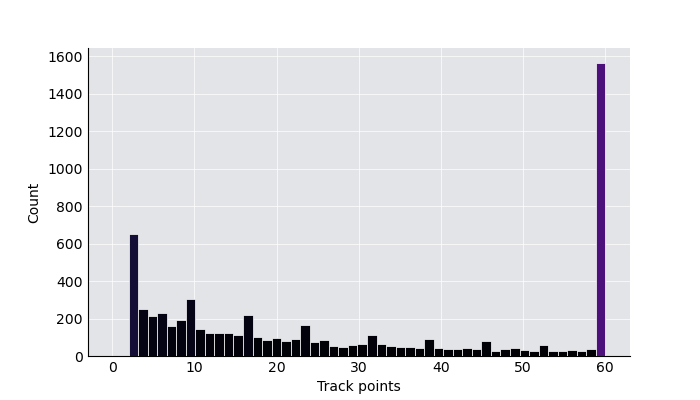

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import SpanSelector

color = "#590d69"

np.random.seed(42)

def threshold_selector_demo(
    df, 
    metric,
    **kwargs
):

    fig, ax = plt.subplots(figsize=(7, 4))

    data = df[metric].to_numpy(float)
    data = data[np.isfinite(data)]

    # draw the histogram
    counts, bins, patches = ax.hist(
        data,
        bins=kwargs.get("bins", "auto"),
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )

    # map counts -> magma colormap
    cmap = plt.get_cmap(kwargs.get("cmap", "magma"))
    norm = plt.Normalize(0, counts.sum())
    base_facecolors = [cmap(norm(c)) for c in counts]
    for patch, fc in zip(patches, base_facecolors):
        patch.set_facecolor(fc)

    ax.set_xlabel(metric)
    ax.set_ylabel("Count")

    for axis in ["top", "right"]:
        ax.spines[axis].set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

    ax.set_facecolor("#e3e4e7")
    ax.grid(True, axis="both", which="major", color="white", linewidth=0.5, zorder=0)

    # store the current selection so it can be used in later cells
    selection = {"min": None, "max": None, "mask": None, "df": None}

    # text labels that follow the two span handles
    _label_kw = dict(
        color="#002fff",
        fontsize=10,
        fontstyle="italic",
        ha="center",
        va="bottom",
        zorder=100000,
        clip_on=False,
    )
    min_label = ax.text(0, 0, "", **_label_kw)
    max_label = ax.text(0, 0, "", **_label_kw)
    min_label.set_visible(False)
    max_label.set_visible(False)

    def onselect(xmin, xmax):
        # guard against a zero-width (single click) selection
        if xmin == xmax:
            selection.update({"min": None, "max": None, "mask": None, "df": None})
            # restore original colormap colors
            for patch, fc in zip(patches, base_facecolors):
                patch.set_facecolor(fc)
            min_label.set_visible(False)
            max_label.set_visible(False)
            fig.canvas.draw_idle()
            return

        mask = (data >= xmin) & (data <= xmax)

        # recolor bars: keep colormap for selected, grey out the rest
        for patch, fc, left_edge, right_edge in zip(
            patches, base_facecolors, bins[:-1], bins[1:]
        ):
            center = 0.5 * (left_edge + right_edge)
            if xmin <= center <= xmax:
                patch.set_facecolor(fc)
            else:
                patch.set_facecolor("darkgrey")

        selection["min"] = xmin
        selection["max"] = xmax
        selection["mask"] = (df[metric].to_numpy(float) >= xmin) & (
            df[metric].to_numpy(float) <= xmax
        )
        selection["df"] = df.loc[selection["mask"]].reset_index(drop=True)

        # position the value labels just above the top of the axes at each handle
        y_top = ax.get_ylim()[1]
        min_label.set_position((xmin, y_top))
        min_label.set_text(f"{xmin:.4g}")
        min_label.set_visible(True)
        max_label.set_position((xmax, y_top))
        max_label.set_text(f"{xmax:.4g}")
        max_label.set_visible(True)

        fig.canvas.draw_idle()
        print(f"{mask.sum()} values in range [{xmin:.4g}, {xmax:.4g}]")

    span = SpanSelector(
        ax,
        onselect,
        "horizontal",
        useblit=True,
        interactive=True,
        drag_from_anywhere=True,
        props=dict(
            alpha=0.2, 
            facecolor="#7E7EE9",
            zorder=2
        ),
        handle_props=dict(
            lw=1.25,
            color='#002fff',
            zorder=99999
        )
    )

    # keep references alive so the widget survives across cells
    fig._span_selector = span
    threshold_selector_demo.selection = selection

    plt.show()

    return selection

# df = df[df["Track points"] > ]

selection = threshold_selector_demo(df, metric="Track points", bins=50)

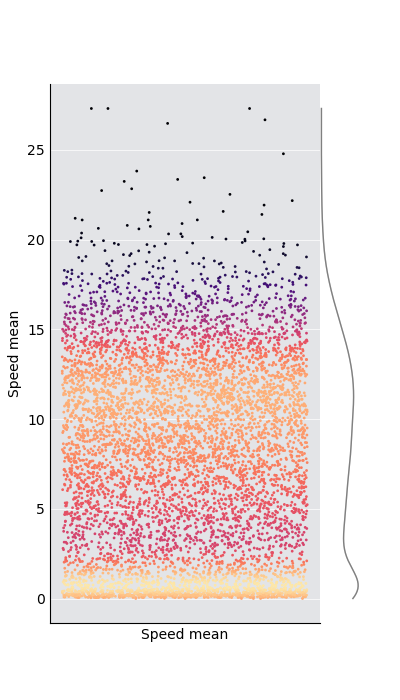

In [10]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

from matplotlib.widgets import SpanSelector
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator, NullFormatter




df = pd.read_csv(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\Track stats 2026-02-22.csv")

np.random.seed(42)


def jitter_selection_demo(
    df,
    metric,
    **kwargs,
):
    log = kwargs.get("log", False)

    fig, ax = plt.subplots(figsize=(4, 7))

    raw = df[metric].to_numpy(float)
    finite = np.isfinite(raw)
    if log:
        finite &= raw > 0
    data = raw[finite]

    # values used for density/KDE (log-transformed when requested)
    kde_vals = np.log(data) if log else data

    x_center = 1.0

    cmap = plt.get_cmap(kwargs.get("cmap", "magma"))

    # --- point density via Gaussian KDE (computed in log-space if log) ---
    density = gaussian_kde(kde_vals, bw_method=kwargs.get("kde_bw", 0.2))(kde_vals)
    dnorm = plt.Normalize(density.min(), density.max() * kwargs.get("density_factor", 1.05))

    # --- jittered scatter overlay, colored by density ---
    jitter = (np.random.rand(len(data)) - 0.5) * kwargs.get("jitter_width", 1)
    xs = np.full(len(data), x_center) + jitter

    base_point_colors = cmap(dnorm(density))
    pts = ax.scatter(
        xs,
        data,  # plot raw values; the log axis handles the scaling
        s=4,
        marker="o",
        c=base_point_colors,
        alpha=kwargs.get("scatter_alpha", 1.0),
        zorder=10,
        edgecolors="none",
    )

    ax.set_ylabel(metric)
    ax.set_xticks([x_center])
    ax.set_xticklabels([metric])
    ax.set_xlim(x_center - 0.55, x_center + 0.55)

    ax.tick_params(axis="both", which="both", length=0)
    ax.grid(True, axis="y", which="major", color="white", linewidth=0.5, zorder=0)
    ax.grid(True, axis="y", which="minor", color="white", linewidth=1, zorder=0, alpha=1)

    if log:
        ax.set_yscale("log", nonpositive="clip")

    for axis in ["top", "right"]:
        ax.spines[axis].set_visible(False)

    ax.set_facecolor("#e3e4e7")

    # --- marginal KDE plot on the right (y) axis ---
    divider = make_axes_locatable(ax)
    ax_right = divider.append_axes("right", size="15%", pad=0, sharey=ax)

    kde_y = gaussian_kde(kde_vals, bw_method=kwargs.get("kde_bw", 0.2))
    grid_kde = np.linspace(kde_vals.min(), kde_vals.max(), 400)
    y_dens = kde_y(grid_kde)
    # y positions in raw data space so the shared log axis lines up
    y_grid = np.exp(grid_kde) if log else grid_kde
    # full KDE drawn in light grey (stays visible outside the selection)
    ax_right.plot(y_dens, y_grid, color="grey", lw=1, zorder=0, alpha=0.25)
    # selected portion drawn on top in the normal grey
    kde_line, = ax_right.plot(y_dens, y_grid, color="grey", lw=1, zorder=2)
    ax_right.set_axis_off()

    ax_sel = ax.twinx()
    # twinx() copies the ORIGINAL axes bounds (before the divider shrank ax),
    # so the selector overlay bled into the marginal KDE axes. Attaching the
    # same axes locator keeps ax_sel exactly on top of the main axes only.
    ax_sel.set_axes_locator(ax.get_axes_locator())
    ax_sel.set_navigate(False)
    ax_sel.set_axis_off()

    def _sel_to_data(v):
        """selector-space value -> raw data value."""
        return np.exp(v) if log else v

    def _data_to_sel(v):
        """raw data value -> selector-space value."""
        return np.log(v) if log else v

    def _sync_sel():
        y0d, y1d = ax.get_ylim()
        ax_sel.set_ylim(_data_to_sel(y0d), _data_to_sel(y1d))

    _sync_sel()
    ax.callbacks.connect("ylim_changed", _sync_sel)

    # store the current selection so it can be used in later cells
    selection = {"min": None, "max": None, "mask": None, "df": None}

    # value labels following the two span handles
    _label_kw = dict(
        color="#002fff",
        fontsize=10,
        fontstyle="italic",
        ha="left",
        va="center",
        zorder=100000,
        clip_on=False,
    )
    min_label = ax.text(0, 0, "", **_label_kw)
    max_label = ax.text(0, 0, "", **_label_kw)
    min_label.set_visible(False)
    max_label.set_visible(False)

    def _edge_density(y_lo, y_hi):
        """KDE density evaluated at the exact selection edges (log-aware)."""
        edge_kde = np.log([y_lo, y_hi]) if log else np.array([y_lo, y_hi])
        return kde_y(edge_kde)

    def onselect(vmin, vmax):
        # vmin/vmax are in selector space (log10 when log). SpanSelector can
        # also return inverted bounds while dragging upwards.
        if vmin > vmax:
            vmin, vmax = vmax, vmin

        # convert selector-space back to raw data values
        ymin = _sel_to_data(vmin)
        ymax = _sel_to_data(vmax)

        # guard against zero-width (single click) selection
        if ymin == ymax:
            selection.update({"min": None, "max": None, "mask": None, "df": None})
            pts.set_facecolors(base_point_colors)
            # restore full KDE line
            kde_line.set_data(y_dens, y_grid)
            min_label.set_visible(False)
            max_label.set_visible(False)
            fig.canvas.draw_idle()
            return

        # mask in raw data space
        mask = (data >= ymin) & (data <= ymax)

        # recolor points: density colors inside, flat grey outside
        colors = base_point_colors.copy()
        colors[~mask] = mcolors.to_rgba(
            "darkgrey", alpha=kwargs.get("scatter_alpha", 1.0)
        )
        pts.set_facecolors(colors)

        # highlight only the selected range on the grey line; interpolate the
        # exact boundary density so the segment does not visually detach
        # (important in log mode where grid spacing widens)
        grid_mask = (y_grid >= ymin) & (y_grid <= ymax)
        edge_dens = _edge_density(ymin, ymax)
        if grid_mask.any():
            seg_y = np.concatenate(([ymin], y_grid[grid_mask], [ymax]))
            seg_d = np.concatenate(([edge_dens[0]], y_dens[grid_mask], [edge_dens[1]]))
            kde_line.set_data(seg_d, seg_y)
        else:
            # selection sits between two grid points: draw just the edges
            kde_line.set_data(edge_dens, [ymin, ymax])

        selection["min"] = ymin
        selection["max"] = ymax
        full = df[metric].to_numpy(float)
        selection["mask"] = (full >= ymin) & (full <= ymax)
        selection["df"] = df.loc[selection["mask"]].reset_index(drop=True)

        # offset the value labels above the ceiling and below the floor;
        # in log mode a multiplicative offset keeps spacing even
        y0, y1 = ax.get_ylim()
        if log:
            y_offset_min = ymin * 0.02
            y_offset_max = ymax * 0.02
        else:
            y_span = y1 - y0
            y_offset_min = y_offset_max = 0.01 * y_span if y_span else 0.0
        x_right = ax.get_xlim()[1]
        max_label.set_position((x_right, ymax + y_offset_max))
        max_label.set_va("bottom")
        max_label.set_text(f"{ymax:.4g}")
        max_label.set_visible(True)
        min_label.set_position((x_right, ymin - y_offset_min))
        min_label.set_va("top")
        min_label.set_text(f"{ymin:.4g}")
        min_label.set_visible(True)

        fig.canvas.draw_idle()
        print(f"{mask.sum()} values in range [{ymin:.4g}, {ymax:.4g}]")

    span = SpanSelector(
        ax_sel,          # linear proxy axis -> uniform dragging in log space
        onselect,
        "vertical",
        useblit=True,
        interactive=True,
        drag_from_anywhere=True,
        props=dict(
            alpha=0.2,
            facecolor="#7E7EE9",
            zorder=4,
        ),
        handle_props=dict(
            lw=1.25,
            color="#002fff",
            zorder=99999,
        ),
    )

    # keep references alive so the widget survives across cells
    fig._span_selector = span
    fig._ax = ax
    jitter_selection_demo.selection = selection

    plt.show()

    return selection


selection = jitter_selection_demo(
    df,
    metric="Speed mean",
    # log=True
)

In [11]:
["#d3d8e1", "#424348", "#24242a", "#4373cd", "#b0b0a8"]

["#365475", "#98bae3", "#5981b1", "#15273c", "#020408"]

['#365475', '#98bae3', '#5981b1', '#15273c', '#020408']

6517 rows in original dataframe
Dropping 17 rows with non-finite/non-positive 'Track length'/'Straightness index' values


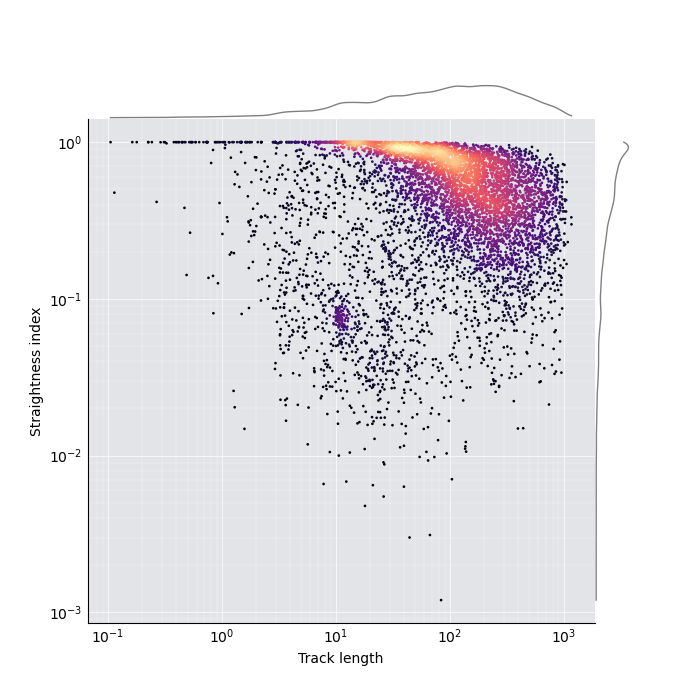

In [124]:
%matplotlib widget

import itertools

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

from matplotlib.path import Path as MplPath
from matplotlib.widgets import PolygonSelector, SpanSelector, Cursor
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import gaussian_kde


class InvalidParameterValueError(ValueError): ...


# ============================================================================
# Base selector
# ============================================================================
class _BaseSelector:
    """Common plumbing: id, styling, selection state, df access."""

    _ids = itertools.count(1)

    # shared style
    ACCENT = "#002fff"
    ACCENT_SOFT = "#002fff4b"
    SPAN_FACE = "#7E7EE9"
    BG = "#e3e4e7"
    GREY_OUT = "darkgrey"

    def __init__(self, df: pd.DataFrame, **kwargs):
        self.id = next(self._ids)
        self.df = df
        self.kwargs = kwargs
        self.cmap = plt.get_cmap(kwargs.get("cmap", "magma"))
        self.selection = {"mask": None, "df": None}
        self.fig = None
        self.ax = None

    # ---- helpers -----------------------------------------------------------
    def _style_ax(self, ax, grid_axis="both"):
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="both", which="both", length=0)
        ax.set_facecolor(self.BG)
        ax.grid(True, axis=grid_axis, which="major", color="white", linewidth=0.5, zorder=0)
        ax.grid(True, axis=grid_axis, which="minor", color="white", linewidth=0.25, zorder=0, alpha=0.75)

    @staticmethod
    def _validate_log(*flags):
        for f in flags:
            if not isinstance(f, bool):
                raise InvalidParameterValueError(f"{f!r} is not a valid log value; must be boolean")

    def _label_kwargs(self, **overrides):
        kw = dict(color=self.ACCENT, fontsize=10, fontstyle="italic",
                  ha="center", va="bottom", zorder=100000, clip_on=False)
        kw.update(overrides)
        return kw

    def _sample(self, df: pd.DataFrame, n: int = 10000, frac: float = None, **kw) -> pd.DataFrame:
        _random_state = kw.get("random_state", 42)
        if frac is not None:
            if not isinstance(frac, float) or not (0 < frac <= 1):
                raise InvalidParameterValueError(f"sample_fraction must be a float between 0 and 1; got {frac!r}")
            return df.sample(frac=frac, random_state=_random_state).reset_index(drop=True)
        elif len(df) > n:
            return df.sample(n=n, random_state=_random_state).reset_index(drop=True)
        else:
            return df

    def _filter_verts(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Apply the selected polygon gate to the *full* dataframe.

        Uses the stored verts and the same log-transform used for display so
        the gate defined on the sampled scatter filters every row of `df`.
        """
        verts = self.selection.get("verts")
        source = self.df if df is None else df
        if verts is None:
            return source.reset_index(drop=True)

        xv = source[self._x].to_numpy(float)
        yv = source[self._y].to_numpy(float)

        finite = np.isfinite(xv) & np.isfinite(yv)
        if self._log_x:
            finite &= xv > 0
        if self._log_y:
            finite &= yv > 0

        inside = np.zeros(len(source), dtype=bool)
        inside[finite] = MplPath(verts).contains_points(
            np.column_stack([xv[finite], yv[finite]])
        )
        return source.loc[inside].reset_index(drop=True)

    def _filter_minmax(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Apply the selected min/max range to the *full* dataframe."""
        source = self.df if df is None else df
        min_val, max_val = self.selection.get("min"), self.selection.get("max")
        if min_val is None or max_val is None:
            return source.reset_index(drop=True)
        mask = (source[self._metric] >= min_val) & (source[self._metric] <= max_val)
        return source.loc[mask].reset_index(drop=True)

    # ---- public API --------------------------------------------------------
    @property
    def result(self) -> dict:
        """Filtered dataframe (raises if nothing selected yet)."""
        return self.selection

    @property
    def mask(self) -> np.ndarray:
        return self.selection["mask"]

    @property
    def range(self) -> dict:
        if self.selection.get("verts", None) is not None:
            return {"verts": self.selection["verts"]}
        elif self.selection.get("min", None) is not None and self.selection.get("max", None) is not None:
            return {"min": self.selection.get("min", None), "max": self.selection.get("max", None)}
        else:
            return {}

    def __repr__(self):
        return f"{type(self).__name__}(id={self.id})"


# ============================================================================
# 2D polygon gate
# ============================================================================
class GateSelector(_BaseSelector):
    """2D density scatter with polygon gating."""

    def show(self, x: str, y: str, *, log: bool = False, **kwargs):
        kw = {**self.kwargs, **kwargs}
        log_x, log_y = kw.get("log_x", log), kw.get("log_y", log)
        self._validate_log(log_x, log_y)

        # remember gate geometry so we can filter the FULL df on the backend
        self._x, self._y = x, y
        self._log_x, self._log_y = log_x, log_y

        df = self._sample(self.df, **kw)

        xdata, ydata = df[x].to_numpy(float), df[y].to_numpy(float)
        finite = np.isfinite(xdata) & np.isfinite(ydata)
        if log_x: finite &= xdata > 0
        if log_y: finite &= ydata > 0
        if (n := int((~finite).sum())):
            print(f"Dropping {n} rows with non-finite/non-positive {x!r}/{y!r} values")
        df = df.loc[finite].reset_index(drop=True)
        xs, ys = xdata[finite], ydata[finite]

        xk = np.log(xs) if log_x else xs
        yk = np.log(ys) if log_y else ys

        bw = kw.get("kde_bw", "scott")
        dens = gaussian_kde(np.vstack([xk, yk]), bw_method=bw)(np.vstack([xk, yk]))

        self.fig, self.ax = plt.subplots(figsize=kw.get("figsize", (7, 7)))
        fig, ax = self.fig, self.ax
        pts = ax.scatter(xs, ys, c=dens, s=0.85, cmap=self.cmap, zorder=3)
        ax.set_xlabel(x); ax.set_ylabel(y)
        if log_x: ax.set_xscale("log", nonpositive="clip")
        if log_y: ax.set_yscale("log", nonpositive="clip")
        self._style_ax(ax)

        # marginal KDEs
        divider = make_axes_locatable(ax)
        for side, vals, is_log in [("top", xk, log_x), ("right", yk, log_y)]:
            m_ax = divider.append_axes(side, size="7%", pad=0,
                                       sharex=ax if side == "top" else None,
                                       sharey=ax if side == "right" else None)
            grid = np.linspace(vals.min(), vals.max(), 400)
            d = gaussian_kde(vals, bw_method=bw)(grid)
            g = np.exp(grid) if is_log else grid
            m_ax.plot(*((g, d) if side == "top" else (d, g)), color="grey", lw=1)
            m_ax.set_axis_off()

        base_colors = pts.get_facecolors().copy()
        # ensure one color per point (scatter may collapse to a single row)
        if len(base_colors) == 1 and len(xs) > 1:
            base_colors = np.repeat(base_colors, len(xs), axis=0)
        self.selection = {"mask": None, "verts": None, "df": None}

        fig._cursor = Cursor(ax, useblit=True, color=self.ACCENT_SOFT,
                             linewidth=1, horizOn=True, vertOn=True)

        # Overlay axes in linear [0, 1] display space so the polygon selector
        # moves/stretches uniformly in pixels regardless of log scaling on `ax`.
        ax_sel = fig.add_axes(ax.get_position(), frameon=False)
        ax_sel.set_axes_locator(ax.get_axes_locator())
        ax_sel.set_xlim(0, 1)
        ax_sel.set_ylim(0, 1)
        ax_sel.set_navigate(False)
        ax_sel.set_axis_off()

        def _sel_to_data(verts):
            """axes-fraction [0,1] verts on ax_sel -> data coords on ax."""
            disp = ax_sel.transAxes.transform(verts)
            return ax.transData.inverted().transform(disp)

        def on_select(verts):
            data_verts = _sel_to_data(verts)
            inside = MplPath(data_verts).contains_points(np.column_stack([xs, ys]))
            colors = base_colors.copy()
            colors[~inside] = mcolors.to_rgba(self.GREY_OUT)
            pts.set_facecolors(colors)
            fig.canvas.draw_idle()
            # store verts; visualized df reflects the sampled subset, but
            # `apply()` / `combined()` re-run the gate on the full dataframe
            self.selection.update(mask=inside, verts=data_verts,
                                  df=df.loc[inside].reset_index(drop=True))
            print(f"[{self!r}] {inside.sum()} points inside gate "
                  f"(of {len(xs)} shown)")

        fig._poly_selector = PolygonSelector(
            ax_sel, on_select, useblit=True,
            props=dict(color=self.ACCENT, lw=1.25, zorder=99999),
            handle_props=dict(markeredgecolor=self.ACCENT, markerfacecolor="white",
                              marker="h", alpha=1, zorder=99999),
        )
        plt.show()
        return self

    def apply(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Apply the selected gate to the *full* dataframe (not just the sampled subset)."""
        return self._filter_verts(df=df)


# ============================================================================
# 1D histogram threshold
# ============================================================================
class ThresholdSelector(_BaseSelector):
    """Histogram with a horizontal SpanSelector for range thresholding (log-aware)."""

    def show(self, metric: str, *, log: bool = False, **kwargs):
        kw = {**self.kwargs, **kwargs}
        self._validate_log(log)
        df = self.df
        self._metric = metric
        
        raw = df[metric].to_numpy(float)
        finite = np.isfinite(raw)
        if log:
            finite &= raw > 0
        data = raw[finite]

        self.fig, self.ax = plt.subplots(figsize=kw.get("figsize", (7, 4)))
        fig, ax = self.fig, self.ax

        # log-spaced bins when requested so bars are visually uniform
        bins_arg = kw.get("bins", "auto")
        if log and isinstance(bins_arg, int):
            bins_arg = np.logspace(np.log10(data.min()), np.log10(data.max()), bins_arg + 1)

        counts, bins, patches = ax.hist(data, bins=bins_arg,
                                        edgecolor="white", linewidth=0.5, zorder=3)
        # norm = plt.Normalize(0, counts.sum())
        norm = plt.Normalize(0, counts.max() * kw.get("density_factor", 1.05))
        base_fc = [self.cmap(norm(c)) for c in counts]
        for p, fc in zip(patches, base_fc):
            p.set_facecolor(fc)

        ax.set_xlabel(metric); ax.set_ylabel("Count")
        if log:
            ax.set_xscale("log", nonpositive="clip")
        self._style_ax(ax)

        # linear proxy axis so span width stays uniform in pixels (log-aware)
        ax_sel = ax.twiny()
        ax_sel.set_axes_locator(ax.get_axes_locator())
        ax_sel.set_navigate(False); ax_sel.set_axis_off()
        to_data = (lambda v: np.exp(v)) if log else (lambda v: v)
        to_sel = (lambda v: np.log(v)) if log else (lambda v: v)

        def _sync():
            lo, hi = ax.get_xlim()
            ax_sel.set_xlim(to_sel(lo), to_sel(hi))
        _sync()
        ax.callbacks.connect("xlim_changed", lambda *_: _sync())

        self.selection = {"min": None, "max": None, "mask": None, "df": None}
        min_lbl = ax.text(0, 0, "", **self._label_kwargs(visible=False))
        max_lbl = ax.text(0, 0, "", **self._label_kwargs(visible=False))

        def onselect(vmin, vmax):
            if vmin > vmax:
                vmin, vmax = vmax, vmin
            xmin, xmax = to_data(vmin), to_data(vmax)

            if xmin == xmax:
                self.selection.update(min=None, max=None, mask=None, df=None)
                for p, fc in zip(patches, base_fc):
                    p.set_facecolor(fc)
                min_lbl.set_visible(False); max_lbl.set_visible(False)
                fig.canvas.draw_idle()
                return

            for p, fc, lo, hi in zip(patches, base_fc, bins[:-1], bins[1:]):
                p.set_facecolor(fc if xmin <= 0.5 * (lo + hi) <= xmax else self.GREY_OUT)

            mask = (raw >= xmin) & (raw <= xmax)
            self.selection.update(min=xmin, max=xmax, mask=mask,
                                  df=df.loc[mask].reset_index(drop=True))

            y_top = ax.get_ylim()[1]
            for lbl, v in [(min_lbl, xmin), (max_lbl, xmax)]:
                lbl.set_position((v, y_top)); lbl.set_text(f"{v:.4g}"); lbl.set_visible(True)

            fig.canvas.draw_idle()
            print(f"[{self!r}] {mask.sum()} values in range [{xmin:.4g}, {xmax:.4g}]")

        fig._span_selector = SpanSelector(
            ax_sel, onselect, "horizontal", useblit=True, interactive=True,
            drag_from_anywhere=True,
            props=dict(alpha=0.2, facecolor=self.SPAN_FACE, zorder=2),
            handle_props=dict(lw=1.25, color=self.ACCENT, zorder=99999),
        )
        plt.show()
        return self

    def apply(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Apply the selected min/max range to the *full* dataframe (not just the sampled subset)."""
        return self._filter_minmax(df=df)


# ============================================================================
# 1D jitter strip
# ============================================================================
class JitterSelector(_BaseSelector):
    """Jittered strip plot with vertical SpanSelector (log-aware)."""

    def show(self, metric: str, *, log: bool = False, **kwargs):
        kw = {**self.kwargs, **kwargs}
        self._validate_log(log)
        df = self.df
        self._metric = metric

        raw = df[metric].to_numpy(float)
        finite = np.isfinite(raw)
        if log: finite &= raw > 0
        data = raw[finite]
        kde_vals = np.log(data) if log else data

        bw = kw.get("kde_bw", 0.2)
        x_center = 1.0

        density = gaussian_kde(kde_vals, bw_method=bw)(kde_vals)
        dnorm = plt.Normalize(density.min(), density.max() * kw.get("density_factor", 1.05))
        base_colors = self.cmap(dnorm(density))

        self.fig, self.ax = plt.subplots(figsize=kw.get("figsize", (4, 7)))
        fig, ax = self.fig, self.ax

        jitter = (np.random.rand(len(data)) - 0.5) * kw.get("jitter_width", 1)
        pts = ax.scatter(np.full(len(data), x_center) + jitter, data, s=4, marker="o",
                         c=base_colors, alpha=kw.get("scatter_alpha", 1.0),
                         zorder=10, edgecolors="none")

        ax.set_ylabel(metric)
        ax.set_xticks([x_center]); ax.set_xticklabels([metric])
        ax.set_xlim(x_center - 0.55, x_center + 0.55)
        if log: ax.set_yscale("log", nonpositive="clip")
        self._style_ax(ax, grid_axis="y")

        # right marginal KDE
        divider = make_axes_locatable(ax)
        ax_right = divider.append_axes("right", size="15%", pad=0, sharey=ax)
        kde_y = gaussian_kde(kde_vals, bw_method=bw)
        grid = np.linspace(kde_vals.min(), kde_vals.max(), 400)
        y_dens = kde_y(grid)
        y_grid = np.exp(grid) if log else grid
        ax_right.plot(y_dens, y_grid, color="grey", lw=1, zorder=0, alpha=0.25)
        kde_line, = ax_right.plot(y_dens, y_grid, color="grey", lw=1, zorder=2)
        ax_right.set_axis_off()

        # linear proxy axis for uniform dragging in log space
        ax_sel = ax.twinx()
        ax_sel.set_axes_locator(ax.get_axes_locator())
        ax_sel.set_navigate(False); ax_sel.set_axis_off()
        to_data = (lambda v: np.exp(v)) if log else (lambda v: v)
        to_sel = (lambda v: np.log(v)) if log else (lambda v: v)

        def _sync():
            lo, hi = ax.get_ylim()
            ax_sel.set_ylim(to_sel(lo), to_sel(hi))
        _sync()
        ax.callbacks.connect("ylim_changed", lambda *_: _sync())

        self.selection = {"min": None, "max": None, "mask": None, "df": None}
        min_lbl = ax.text(0, 0, "", **self._label_kwargs(ha="left", va="top", visible=False))
        max_lbl = ax.text(0, 0, "", **self._label_kwargs(ha="left", va="bottom", visible=False))

        def onselect(vmin, vmax):
            if vmin > vmax:
                vmin, vmax = vmax, vmin
            ymin, ymax = to_data(vmin), to_data(vmax)

            if ymin == ymax:
                self.selection.update(min=None, max=None, mask=None, df=None)
                pts.set_facecolors(base_colors)
                kde_line.set_data(y_dens, y_grid)
                min_lbl.set_visible(False); max_lbl.set_visible(False)
                fig.canvas.draw_idle()
                return

            local_mask = (data >= ymin) & (data <= ymax)
            colors = base_colors.copy()
            colors[~local_mask] = mcolors.to_rgba(self.GREY_OUT, alpha=kw.get("scatter_alpha", 1.0))
            pts.set_facecolors(colors)

            # highlight selected KDE segment with interpolated edges
            gm = (y_grid >= ymin) & (y_grid <= ymax)
            edges = kde_y(np.log([ymin, ymax]) if log else np.array([ymin, ymax]))
            if gm.any():
                kde_line.set_data(np.concatenate(([edges[0]], y_dens[gm], [edges[1]])),
                                  np.concatenate(([ymin], y_grid[gm], [ymax])))
            else:
                kde_line.set_data(edges, [ymin, ymax])

            mask = (raw >= ymin) & (raw <= ymax)
            self.selection.update(min=ymin, max=ymax, mask=mask,
                                  df=df.loc[mask].reset_index(drop=True))

            y0, y1 = ax.get_ylim()
            off_min = ymin * 0.02 if log else 0.01 * (y1 - y0)
            off_max = ymax * 0.02 if log else 0.01 * (y1 - y0)
            x_right = ax.get_xlim()[1]
            max_lbl.set_position((x_right, ymax + off_max)); max_lbl.set_text(f"{ymax:.4g}"); max_lbl.set_visible(True)
            min_lbl.set_position((x_right, ymin - off_min)); min_lbl.set_text(f"{ymin:.4g}"); min_lbl.set_visible(True)

            fig.canvas.draw_idle()
            print(f"[{self!r}] {local_mask.sum()} values in range [{ymin:.4g}, {ymax:.4g}]")

        fig._span_selector = SpanSelector(
            ax_sel, onselect, "vertical", useblit=True, interactive=True,
            drag_from_anywhere=True,
            props=dict(alpha=0.2, facecolor=self.SPAN_FACE, zorder=4),
            handle_props=dict(lw=1.25, color=self.ACCENT, zorder=99999),
        )
        plt.show()
        return self

    def apply(self, df: pd.DataFrame = None) -> pd.DataFrame:
        """Apply the selected min/max range to the *full* dataframe (not just the sampled subset)."""
        return self._filter_minmax(df=df)


# ============================================================================
# Facade / registry
# ============================================================================
class DataFilter:
    """
    Facade holding a dataframe and a registry of interactive selectors.

    Usage:
        f = DataFilter(df)
        g = f.gate(x="Track length", y="Straightness index", log_x=True)
        t = f.threshold("Track points", bins=50)
        j = f.jitter("Speed mean", log=True)

        # after interacting with the plots:
        g.result            # filtered df from the gate (sampled subset)
        g.apply()           # gate applied to the FULL df
        f.combined()        # df passing ALL active selections (full df)
        f.selectors         # {id: selector} registry
    """

    def __init__(self, df: pd.DataFrame = pd.DataFrame(), seed: int = 42, **default_kwargs):
        np.random.seed(seed)
        self.df = df
        self.default_kwargs = default_kwargs
        self.selectors: dict[int, _BaseSelector] = {}

    def _register(self, sel: _BaseSelector) -> _BaseSelector:
        self.selectors[sel.id] = sel
        return sel

    # ---- factory methods ---------------------------------------------------
    def gate(self, df: pd.DataFrame, x: str, y: str, **kwargs) -> GateSelector:
        sel = GateSelector(df, **{**self.default_kwargs, **kwargs})
        return self._register(sel.show(x, y, **kwargs))

    def threshold(self, df: pd.DataFrame, metric: str, **kwargs) -> ThresholdSelector:
        sel = ThresholdSelector(df, **{**self.default_kwargs, **kwargs})
        return self._register(sel.show(metric, **kwargs))

    def jitter(self, df: pd.DataFrame, metric: str, **kwargs) -> JitterSelector:
        sel = JitterSelector(df, **{**self.default_kwargs, **kwargs})
        return self._register(sel.show(metric, **kwargs))


# ============================================================================
# Example usage
# ============================================================================
df = pd.read_csv(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\Track stats 2026-02-22.csv")

f = DataFilter()

print(len(df), "rows in original dataframe")

gate_sel = f.gate(df, "Track length", "Straightness index", log=True, kde_bw=0.1)



# thresh_sel = f.threshold(df, "Track points", bins=50)
# jitter_sel = f.jitter(df, "Speed mean", log=False)

# After interacting:
#   gate_sel.result       -> filtered df from that widget (sampled subset)
#   gate_sel.apply()      -> gate applied to the FULL df
#   gate_sel.apply(df)    -> same gate applied to any df
#   f.combined()          -> df passing all active selections (full df)
#   f.selectors           -> {id: selector}

In [125]:
gated = gate_sel.apply()
gated

,Condition,Replicate,Track ID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed sem,Speed median,Speed q25,Speed q75,Speed ci95 low,Speed ci95 high,Track displacement,Straightness index,Track points,Direction mean,Direction var
0,naive-ctr,BC39,0.0,630.967270,0.111037,19.703638,10.694361,7.033905,0.915736,14.203164,0.745758,16.106404,8.973317,12.248886,257.145192,0.407541,60,-1.541829,7.352325e-01
1,naive-ctr,BC39,1.0,40.134674,0.139915,2.356252,0.680249,0.487789,0.063505,0.511331,0.370752,0.828070,0.574183,0.816507,6.307333,0.157154,60,2.771387,9.090958e-01
2,naive-ctr,BC39,2.0,560.893672,6.378677,17.352286,12.193341,2.553909,0.376553,12.853814,10.090823,13.955698,11.392498,12.874678,272.151638,0.485211,47,-3.135888,5.717380e-01
3,naive-ctr,BC39,3.0,529.210491,4.725620,11.239372,8.969669,1.330197,0.173177,8.969716,8.344718,9.796072,8.604490,9.260695,261.629161,0.494376,60,1.150420,5.052205e-01
4,naive-ctr,BC39,4.0,37.818738,0.059585,8.121626,1.719034,1.820797,0.388195,1.038797,0.638763,1.906295,1.230830,2.827508,2.407204,0.063651,23,0.506208,9.595911e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6512,naive-mu,BC43,206.0,0.378982,0.378982,0.378982,0.378982,NaN,NaN,0.378982,0.378982,0.378982,NaN,NaN,0.378982,1.000000,2,2.436283,0.000000e+00
6513,naive-mu,BC43,207.0,1.237509,1.237509,1.237509,1.237509,NaN,NaN,1.237509,1.237509,1.237509,NaN,NaN,1.237509,1.000000,2,-0.325209,0.000000e+00
6514,naive-mu,BC43,208.0,0.479739,0.479739,0.479739,0.479739,NaN,NaN,0.479739,0.479739,0.479739,NaN,NaN,0.479739,1.000000,2,2.070479,0.000000e+00
6515,naive-mu,BC43,209.0,0.105575,0.105575,0.105575,0.105575,NaN,NaN,0.105575,0.105575,0.105575,NaN,NaN,0.105575,1.000000,2,1.798401,0.000000e+00


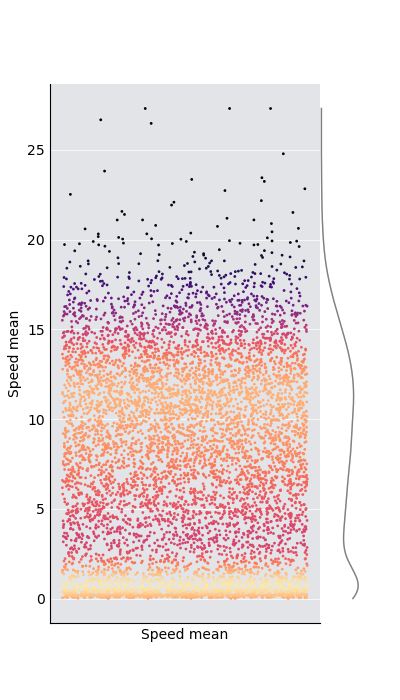

In [131]:
jitter_sel = f.jitter(gated, "Speed mean", log=False)

In [132]:
jitter_sel.apply()

,Condition,Replicate,Track ID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed sem,Speed median,Speed q25,Speed q75,Speed ci95 low,Speed ci95 high,Track displacement,Straightness index,Track points,Direction mean,Direction var
0,naive-ctr,BC39,0.0,630.967270,0.111037,19.703638,10.694361,7.033905,0.915736,14.203164,0.745758,16.106404,8.973317,12.248886,257.145192,0.407541,60,-1.541829,7.352325e-01
1,naive-ctr,BC39,1.0,40.134674,0.139915,2.356252,0.680249,0.487789,0.063505,0.511331,0.370752,0.828070,0.574183,0.816507,6.307333,0.157154,60,2.771387,9.090958e-01
2,naive-ctr,BC39,2.0,560.893672,6.378677,17.352286,12.193341,2.553909,0.376553,12.853814,10.090823,13.955698,11.392498,12.874678,272.151638,0.485211,47,-3.135888,5.717380e-01
3,naive-ctr,BC39,3.0,529.210491,4.725620,11.239372,8.969669,1.330197,0.173177,8.969716,8.344718,9.796072,8.604490,9.260695,261.629161,0.494376,60,1.150420,5.052205e-01
4,naive-ctr,BC39,4.0,37.818738,0.059585,8.121626,1.719034,1.820797,0.388195,1.038797,0.638763,1.906295,1.230830,2.827508,2.407204,0.063651,23,0.506208,9.595911e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6512,naive-mu,BC43,206.0,0.378982,0.378982,0.378982,0.378982,NaN,NaN,0.378982,0.378982,0.378982,NaN,NaN,0.378982,1.000000,2,2.436283,0.000000e+00
6513,naive-mu,BC43,207.0,1.237509,1.237509,1.237509,1.237509,NaN,NaN,1.237509,1.237509,1.237509,NaN,NaN,1.237509,1.000000,2,-0.325209,0.000000e+00
6514,naive-mu,BC43,208.0,0.479739,0.479739,0.479739,0.479739,NaN,NaN,0.479739,0.479739,0.479739,NaN,NaN,0.479739,1.000000,2,2.070479,0.000000e+00
6515,naive-mu,BC43,209.0,0.105575,0.105575,0.105575,0.105575,NaN,NaN,0.105575,0.105575,0.105575,NaN,NaN,0.105575,1.000000,2,1.798401,0.000000e+00


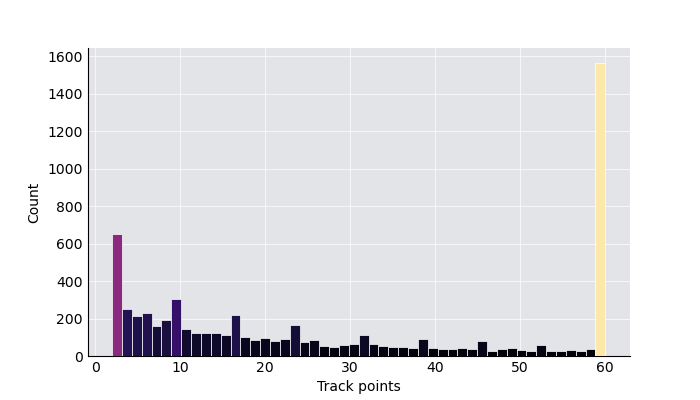

In [133]:
threshold_sel = f.threshold(gated, "Track points", bins=50)

In [136]:
threshold_sel.apply()

,Condition,Replicate,Track ID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed sem,Speed median,Speed q25,Speed q75,Speed ci95 low,Speed ci95 high,Track displacement,Straightness index,Track points,Direction mean,Direction var
0,naive-ctr,BC39,30.0,427.971012,8.627075,14.559284,11.566784,1.583535,0.260332,11.809809,10.151705,12.847734,11.100356,12.073689,330.527180,0.772312,38,-2.144824e+00,0.225571
1,naive-ctr,BC39,31.0,457.508696,8.237272,14.609866,12.039703,1.426510,0.231410,11.873012,11.265649,13.036805,11.571157,12.479281,374.948040,0.819543,39,-1.866841e+00,0.190335
2,naive-ctr,BC39,44.0,325.673893,0.540364,16.090240,8.350613,4.833519,0.773983,10.118334,3.071062,11.844761,6.825526,9.784694,263.592285,0.809375,40,-2.302491e+00,0.239154
3,naive-ctr,BC39,56.0,158.251054,0.020898,20.184736,3.956276,7.263618,1.148479,0.430444,0.280166,0.901880,2.208967,6.789078,130.217202,0.822852,41,1.396558e+00,0.719979
4,naive-ctr,BC39,65.0,226.336255,0.605948,11.144808,5.520396,2.569367,0.401268,5.148710,3.437115,7.634026,4.739997,6.300568,54.672908,0.241556,42,-9.633642e-02,0.705071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,naive-mu,BC42 (fresh),383.0,324.502140,1.157549,13.453116,8.539530,3.267270,0.530021,9.245758,6.458521,11.108815,7.382500,9.482809,112.469889,0.346592,39,-2.822934e+00,0.819120
204,naive-mu,BC42 (fresh),386.0,51.037172,0.311937,4.793834,1.343083,0.921351,0.149463,1.168026,0.712748,1.799320,1.078096,1.688168,4.459312,0.087374,39,-2.197261e+00,0.862040
205,naive-mu,BC43,54.0,142.584455,0.447654,9.241720,3.564611,2.316454,0.366264,3.331318,1.438693,5.132842,2.907536,4.371189,94.938542,0.665841,41,-2.173174e+00,0.345264
206,naive-mu,BC43,68.0,9.596451,0.000000,0.738189,0.239911,0.350154,0.055364,0.000000,0.000000,0.738189,0.147638,0.350640,0.738189,0.076923,41,3.297126e-17,0.350000


In [34]:
f.threshold?

Signature: f.threshold(df: pandas.core.frame.DataFrame, metric: str, **kwargs) -> __main__.ThresholdSelector
Docstring: osohdvoisahv 
File:      c:\users\modri\appdata\local\temp\ipykernel_21536\1856397506.py
Type:      method

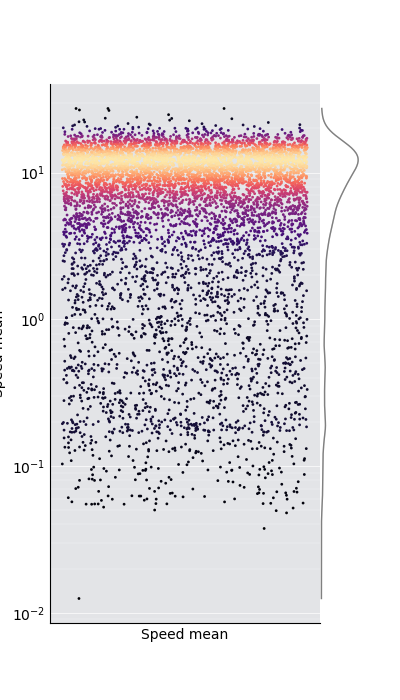

In [77]:
jitter_sel = f.jitter(df, "Speed mean", log=True, kde_bw=0.1)

In [79]:
jitter_sel.range

{'min': np.float64(0.22310816458585553), 'max': np.float64(5.309129637762126)}

In [90]:
plt.close('all')